In [1]:
import torch
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModelForObjectDetection

import matplotlib.pyplot as plt
from PIL import ImageDraw

### Load CPPE-5 dataset

In [2]:
cppe5 = load_dataset("cppe-5")
print(cppe5)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/237M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/4.14M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/29 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 29
    })
})


*Make validation split*

In [3]:
split = cppe5["train"].train_test_split(test_size=0.15, seed=42)

train_raw = split["train"]
val_raw = split["test"]
test_raw = cppe5["test"]

print("Train:", len(train_raw))
print("Val  :", len(val_raw))
print("Test :", len(test_raw))

Train: 850
Val  : 150
Test : 29


*Label names*

In [4]:
label_names = ["Coverall", "Face_Shield", "Gloves", "Goggles", "Mask"]

id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

print(id2label)

{0: 'Coverall', 1: 'Face_Shield', 2: 'Gloves', 3: 'Goggles', 4: 'Mask'}


Image ID: 9
Image size: (200, 200)
Categories: [4, 4, 0]
BBoxes: [[146.0, 86.0, 54.0, 40.0], [33.0, 22.0, 18.0, 17.0], [2.0, 3.0, 69.0, 197.0]]


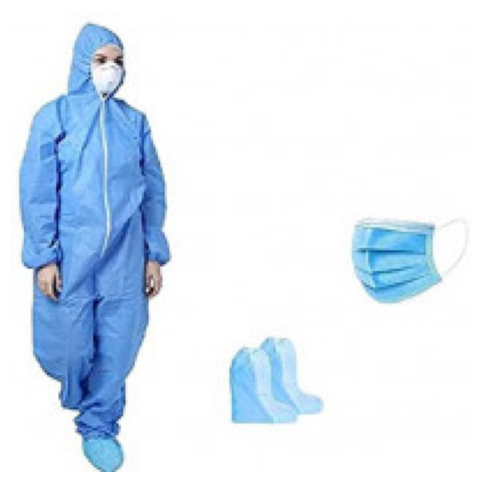

In [5]:
sample = train_raw[0]

image = sample["image"]
objects = sample["objects"]

print("Image ID:", sample["image_id"])
print("Image size:", image.size)
print("Categories:", objects["category"])
print("BBoxes:", objects["bbox"])

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

### Draw ground-truth boxes

In [6]:
def draw_ground_truth(image, objects, id2label):
    image = image.copy()
    draw = ImageDraw.Draw(image)
    
    for category, bbox in zip(objects["category"], objects["bbox"]):
        x, y, w, h = bbox
        x2 = x + w
        y2 = y + h
        draw.rectangle([x, y, x2, y2], outline="lime", width=3)
        draw.text((x, y), id2label[int(category)], fill="lime")
    
    return image

*Visualize ground truth*

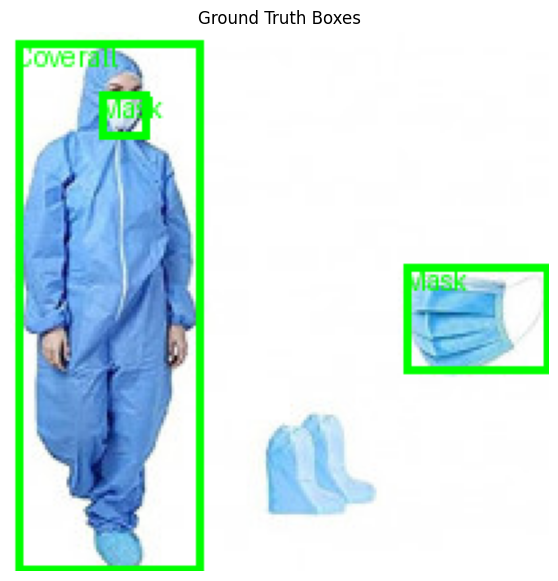

In [7]:
gt_image = draw_ground_truth(sample["image"], sample["objects"], id2label)

plt.figure(figsize=(7, 7))
plt.imshow(gt_image)
plt.axis("off")
plt.title("Ground Truth Boxes")
plt.show()

### Load image processor

In [8]:
MODEL_NAME = "microsoft/conditional-detr-resnet-50"
IMAGE_SIZE = 480

image_processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME,
    do_resize=True,
    size={"max_height": IMAGE_SIZE, "max_width": IMAGE_SIZE},
    do_pad=True,
    pad_size={"height": IMAGE_SIZE, "width": IMAGE_SIZE},
)

print(image_processor)

preprocessor_config.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

The image processor of type `ConditionalDetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


ConditionalDetrImageProcessorFast {
  "data_format": "channels_first",
  "do_convert_annotations": true,
  "do_normalize": true,
  "do_pad": true,
  "do_rescale": true,
  "do_resize": true,
  "format": "coco_detection",
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "ConditionalDetrImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "pad_size": {
    "height": 480,
    "width": 480
  },
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "max_height": 480,
    "max_width": 480
  }
}

